# DPO v2 Training — c5

Fine-tunes GPT-4.1-nano on the cleaned DPO v2 dataset (NEG4 dropped, NEG2 expanded to 1250).
Covers: data conversion, file upload, job submission, monitoring, and label-accuracy evaluation.

In [ ]:
import os
import json
import time
import re
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential

os.chdir("/Users/zheng/CIS527-RL")
print("Working directory:", os.getcwd())

RESOURCE_GROUP = "cis-5270-team-10"
OPENAI_API_KEY = ""

OPENAI_ENDPOINT = f"https://{RESOURCE_GROUP}.openai.azure.com"
SUBSCRIPTION_ID = ""

os.environ["AZURE_SUBSCRIPTION_ID"] = SUBSCRIPTION_ID
os.environ["AZURE_RESOURCE_GROUP"]  = "CIS-5270"
os.environ["AZURE_AOAI_ACCOUNT"]    = RESOURCE_GROUP
os.environ["AZURE_OPENAI_API_KEY"]  = OPENAI_API_KEY
os.environ["AZURE_OPENAI_ENDPOINT"] = OPENAI_ENDPOINT

CREDENTIAL = DefaultAzureCredential()

openai_client = AzureOpenAI(
    api_key=OPENAI_API_KEY,
    azure_endpoint=OPENAI_ENDPOINT,
    api_version="2025-04-01-preview",
)

BASE_MODEL = "gpt-4.1-nano-2025-04-14"

random.seed(42)

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def save_jsonl(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

print("Connected to Azure OpenAI")

Working directory: /Users/zheng/CIS527-RL
Connected to Azure OpenAI


## Step 1: Convert, Upload Training and Validation Files

Convert `dpo_data_v2_3k.jsonl` to Azure DPO format and upload.
Reuses `dpo_val_azure.jsonl` from the c1–c4 run (same 300-row val set).

In [3]:
DPO_V2_DATA_PATH   = "data/generated/dpo_data_v2_3k.jsonl"
DPO_V2_UPLOAD_PATH = "data/generated/dpo_v2_train_azure.jsonl"
DPO_VAL_PATH       = "data/generated/dpo_val_azure.jsonl"

SYSTEM_PROMPT = """You are a fact-checking assistant. Given a passage and a claim, write a one-sentence justification using this structure:
1. Quote or closely paraphrase the most relevant part of the passage.
2. State how that evidence supports the verdict.

Format your full response as: LABEL: justification sentence
Label must be one of: SUPPORTED, CONTRADICTED, NOT MENTIONED

The justification must lead with the evidence, not the conclusion."""

def convert_train_row(row):
    return {
        "input": {
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": row["prompt"]},
            ]
        },
        "preferred_output":     [{"role": "assistant", "content": row["chosen"]}],
        "non_preferred_output": [{"role": "assistant", "content": row["rejected"]}],
    }

raw = load_jsonl(DPO_V2_DATA_PATH)
converted = []
for row in raw:
    try:
        chosen   = row["chosen"].strip()
        rejected = row["rejected"].strip()
        prompt   = row["prompt"].strip()
    except Exception:
        continue
    if not chosen or not rejected or not prompt or chosen == rejected:
        continue
    converted.append(convert_train_row(row))

save_jsonl(DPO_V2_UPLOAD_PATH, converted)
print(f"DPO v2 train: {len(converted)} rows saved to {DPO_V2_UPLOAD_PATH}")
print("Neg type breakdown:", Counter(r["neg_type"] for r in raw))

print("\nUploading DPO v2 training file...")
with open(DPO_V2_UPLOAD_PATH, "rb") as f:
    dpo_train_file = openai_client.files.create(file=f, purpose="fine-tune")
dpo_train_file_id = dpo_train_file.id
print(f"DPO v2 training file id: {dpo_train_file_id}")

print("Uploading DPO validation file...")
with open(DPO_VAL_PATH, "rb") as f:
    dpo_val_file = openai_client.files.create(file=f, purpose="fine-tune")
dpo_val_file_id = dpo_val_file.id
print(f"DPO val file id: {dpo_val_file_id}")

print("Waiting for file processing...")
openai_client.files.wait_for_processing(dpo_train_file_id)
openai_client.files.wait_for_processing(dpo_val_file_id)
print("Files ready!")

DPO v2 train: 3000 rows saved to data/generated/dpo_v2_train_azure.jsonl
Neg type breakdown: Counter({'neg2_bad_reasoning': 1250, 'neg1_wrong_label': 750, 'neg6_mismatch': 500, 'neg5_degenerate': 250, 'neg3_hedge': 250})

Uploading DPO v2 training file...
DPO v2 training file id: file-2fa96d1cf29148d18d0a1337f7710e2d
Uploading DPO validation file...
DPO val file id: file-2ca1c8032b7746c69e9d17f4283ea085
Waiting for file processing...
Files ready!


## Step 2: Submit Fine-Tuning Job

| Config | LR multiplier | Epochs | Batch size |
|--------|--------------|--------|------------|
| dpo_v2_c5 | 1 | 1 | 1 |

In [4]:
job = openai_client.fine_tuning.jobs.create(
    model=BASE_MODEL,
    training_file=dpo_train_file_id,
    validation_file=dpo_val_file_id,
    method={
        "type": "dpo",
        "dpo": {
            "hyperparameters": {
                "n_epochs":                 1,
                "batch_size":               1,
                "learning_rate_multiplier": 1.0,
            },
        },
    },
    extra_body={"trainingType": "GlobalStandard"},
    suffix="dpo_v2_c5",
)

job_id = job.id
print(f"dpo_v2_c5: job_id={job_id}  status={job.status}")

dpo_v2_c5: job_id=ftjob-4a7d86e9fe0b495989c74f9a9a453f43  status=pending


## Step 3: Monitor Job and Collect Loss Curves

In [8]:
def monitor_job(job_id, poll_interval=60):
    scraped = []
    result_file_id = None
    seen_steps = set()

    while True:
        job = openai_client.fine_tuning.jobs.retrieve(job_id)

        if job.status in ("succeeded", "failed", "cancelled"):
            print(f"dpo_v2_c5: {job.status}  model={job.fine_tuned_model}")
            if job.result_files:
                result_file_id = job.result_files[0]
                print(f"  result file: {result_file_id}")
            break

        events = []
        after = None
        while True:
            page = openai_client.fine_tuning.jobs.list_events(job_id, limit=100, after=after)
            batch = list(page)
            if not batch:
                break
            events.extend(batch)
            after = batch[-1].id
            if len(batch) < 100:
                break

        for ev in reversed(events):
            m = re.search(r"Step\s+(\d+).*?loss[=:\s]+([0-9.]+)", ev.message, re.IGNORECASE)
            if m:
                step = int(m.group(1))
                if step not in seen_steps:
                    seen_steps.add(step)
                    scraped.append({"step": step, "loss": float(m.group(2))})

        latest = events[0].message if events else "no events"
        print(f"dpo_v2_c5: {job.status} | pts={len(scraped)} | {latest[:80]}")
        print(f"  waiting {poll_interval}s...")
        time.sleep(poll_interval)

    os.makedirs("data/results", exist_ok=True)
    scraped_path = "data/results/dpo_v2_c5_loss_curves.json"
    with open(scraped_path, "w") as f:
        json.dump({"dpo_v2_c5": scraped}, f, indent=2)
    print(f"scraped loss curves saved to {scraped_path}")
    return scraped, result_file_id

scraped_curves, result_file_id = monitor_job(job_id)

dpo_v2_c5: running | pts=186 | Step 1850: training loss=0.0003147125244140625
  waiting 60s...
dpo_v2_c5: running | pts=186 | Step 1850: training loss=0.0003147125244140625
  waiting 60s...
dpo_v2_c5: running | pts=186 | Step 1850: training loss=0.0003147125244140625
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training loss=5.245208740234375E-05
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training loss=5.245208740234375E-05
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training loss=5.245208740234375E-05
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training loss=5.245208740234375E-05
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training loss=5.245208740234375E-05
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training loss=5.245208740234375E-05
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training loss=5.245208740234375E-05
  waiting 60s...
dpo_v2_c5: running | pts=190 | Step 1890: training

## Fine-Tuned Model ID

Paste the model ID reported above after the job completes:

- dpo_v2_c5: `gpt-4.1-nano-2025-04-14.ft-4a7d86e9fe0b495989c74f9a9a453f43-dpo_v2_c5`

In [9]:
import csv
import io

def safe_float(s):
    try: return float(s)
    except: return None

def fetch_clean_curves(result_file_id, name="dpo_v2_c5"):
    content = openai_client.files.content(result_file_id).read().decode("utf-8")
    rows = list(csv.DictReader(io.StringIO(content)))
    steps           = [int(r["step"]) for r in rows]
    train_loss      = [safe_float(r.get("train_loss")) for r in rows]
    valid_loss      = [safe_float(r.get("valid_loss")) for r in rows]
    full_valid_loss = [safe_float(r.get("full_valid_loss")) for r in rows]
    full_valid_acc  = [safe_float(r.get("full_valid_mean_token_accuracy")) for r in rows]
    curves = {
        name: {
            "steps": steps,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "full_valid_loss": full_valid_loss,
            "full_valid_acc": full_valid_acc,
        }
    }
    print(f"{name}: {len(rows)} rows from result file {result_file_id}")
    tl = [v for v in train_loss if v is not None]
    vl = [v for v in valid_loss if v is not None]
    print(f"  Final train loss: {tl[-1]:.4f}  Final val loss: {vl[-1] if vl else float('nan'):.4f}  Min val: {min(vl) if vl else float('nan'):.4f}")
    return curves

clean_curves = fetch_clean_curves(result_file_id)

CLEAN_PATH = "data/results/dpo_v2_c5_loss_curves_clean.json"
with open(CLEAN_PATH, "w") as f:
    json.dump(clean_curves, f, indent=2)
print(f"clean curves saved to {CLEAN_PATH}")

dpo_v2_c5: 3000 rows from result file file-0d38b6e526414b3e8032576f6377a6bc
  Final train loss: 0.0001  Final val loss: 0.5503  Min val: 0.0505
clean curves saved to data/results/dpo_v2_c5_loss_curves_clean.json


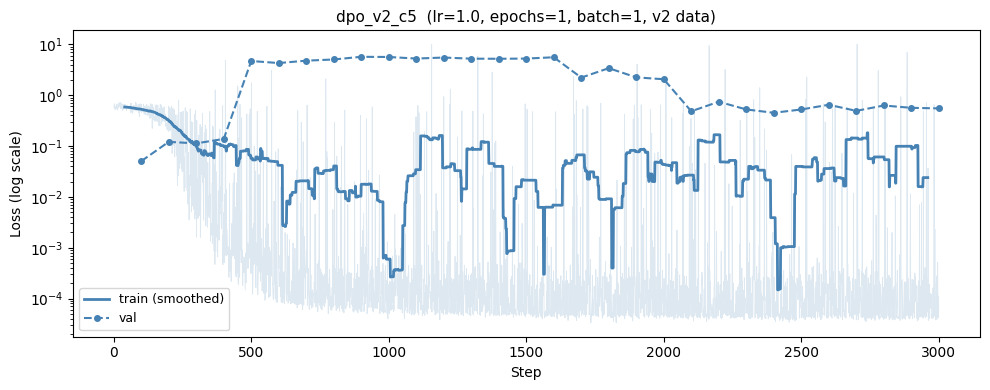

saved to data/results/dpo_v2_c5_loss_curves.png


In [10]:
def smooth(values, window=50):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

data = clean_curves["dpo_v2_c5"]
color = "steelblue"
WINDOW = 80

train_pts = [(s, v) for s, v in zip(data["steps"], data["train_loss"]) if v is not None and v > 0]
valid_pts = [(s, v) for s, v in zip(data["steps"], data["valid_loss"]) if v is not None and v > 0]
steps_t = np.array([s for s, v in train_pts])
loss_t  = np.array([v for s, v in train_pts])

fig, ax = plt.subplots(figsize=(10, 4))

if len(loss_t) > WINDOW:
    smoothed = smooth(loss_t, WINDOW)
    trim = (len(steps_t) - len(smoothed)) // 2
    steps_s = steps_t[trim: trim + len(smoothed)]
    ax.semilogy(steps_t, loss_t, color=color, alpha=0.18, linewidth=0.6)
    ax.semilogy(steps_s, smoothed, color=color, linewidth=2, label="train (smoothed)")
else:
    ax.plot(steps_t, loss_t, color=color, linewidth=1.2, label="train")

if valid_pts:
    ax.plot([s for s, v in valid_pts], [v for s, v in valid_pts],
            color=color, linestyle="--", linewidth=1.5, marker="o", markersize=4, label="val")

ax.set_title("dpo_v2_c5  (lr=1.0, epochs=1, batch=1, v2 data)", fontsize=11)
ax.set_xlabel("Step")
ax.set_ylabel("Loss (log scale)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("data/results/dpo_v2_c5_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved to data/results/dpo_v2_c5_loss_curves.png")

## Step 4: Set Deployment Name

After deploying the fine-tuned model, set the deployment name below.

In [11]:
DPO_V2_C5_DEPLOYMENT = "1-nano-2025-04-14-dpo_v2_c5"  # set after deploying

## Step 5: Evaluate on Dev Set

In [12]:
VALID_LABELS = {"SUPPORTED", "CONTRADICTED", "NOT MENTIONED"}

def extract_label(text):
    if not isinstance(text, str) or not text.strip():
        return None
    t = text.upper().strip()
    t = re.sub(r'^[\s\-\*\#\:\"]+'  , '', t)
    t = re.sub(r"\bNOT\s+MENTION\b", "NOT MENTIONED", t)
    prefix = " ".join(t.split()[:8])
    if re.match(r"^(SUPPORTED|SUPPORT|SUPPORTS|SUPPORTED,|SUPPORTED:)\b", prefix):
        return "SUPPORTED"
    if re.match(r"^(CONTRADICTED|CONTRADICTS|CONTRADICT|REFUTED|REFUTES|REFUTE)\b", prefix):
        return "CONTRADICTED"
    if re.match(r"^(CON\b|CON,|CON:|CON\s)", prefix):
        return "CONTRADICTED"
    if re.match(r"^(NOT MENTIONED|NOT\s+MENTION|NOT\s+M\b|NEI|NOT ENOUGH INFO)\b", prefix):
        return "NOT MENTIONED"
    label_positions = []
    patterns = {
        "SUPPORTED":     r"\bSUPPORTED\b",
        "CONTRADICTED":  r"\bCONTRADICTED\b|\bREFUTED\b",
        "NOT MENTIONED": r"\bNOT MENTIONED\b|\bNOT ENOUGH INFO\b|\bNEI\b",
    }
    for label, pattern in patterns.items():
        m = re.search(pattern, t)
        if m:
            label_positions.append((m.start(), label))
    if label_positions:
        return sorted(label_positions)[0][1]
    return None

def predict(passage, claim, deployment, temperature=0.0):
    user_msg = f"Passage: {passage}\n\nClaim: {claim}"
    for attempt in range(3):
        try:
            resp = openai_client.chat.completions.create(
                model=deployment,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": user_msg},
                ],
                temperature=temperature,
                max_tokens=150,
            )
            text = resp.choices[0].message.content.strip()
            label = extract_label(text)
            if label:
                return label, text
        except Exception as e:
            if attempt < 2:
                time.sleep(2 ** attempt)
            else:
                print(f"  failed after 3 attempts: {e}")
    return None, None

def run_eval(deployment, examples, out_path):
    done_ids = set()
    results = []
    if os.path.exists(out_path):
        with open(out_path) as f:
            for line in f:
                r = json.loads(line)
                done_ids.add(r["id"])
                results.append(r)
        print(f"resuming, {len(done_ids)} already done")

    skipped = 0
    with open(out_path, "a") as out_f:
        for i, ex in enumerate(examples):
            if ex["id"] in done_ids:
                continue
            pred_label, raw = predict(ex["passage"], ex["claim"], deployment)
            if pred_label is None:
                skipped += 1
                continue
            record = {"id": ex["id"], "label": ex["label"], "pred_label": pred_label, "raw": raw}
            out_f.write(json.dumps(record) + "\n")
            out_f.flush()
            results.append(record)
            if (i + 1) % 100 == 0:
                print(f"  [{i+1}/{len(examples)}] skipped={skipped}")

    print(f"done. total={len(results)} skipped={skipped}")
    return results

In [13]:
random.seed(42)

dev_data = load_jsonl("data/joined/fever_dev_joined.jsonl")

buckets = defaultdict(list)
for ex in dev_data:
    buckets[ex["label"]].append(ex)

eval_sample = []
for lbl, items in buckets.items():
    random.shuffle(items)
    eval_sample.extend(items[:400])
random.shuffle(eval_sample)

print(f"dev sample: {len(eval_sample)} examples")
print(Counter(ex["label"] for ex in eval_sample))

dev sample: 1200 examples
Counter({'CONTRADICTED': 400, 'SUPPORTED': 400, 'NOT MENTIONED': 400})


In [14]:
print(f"Evaluating dpo_v2_c5  deployment: {DPO_V2_C5_DEPLOYMENT}")
dev_results = run_eval(DPO_V2_C5_DEPLOYMENT, eval_sample, "data/results/dpo_v2_c5_dev.jsonl")

Evaluating dpo_v2_c5  deployment: 1-nano-2025-04-14-dpo_v2_c5
  failed after 3 attempts: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt triggering Azure OpenAI's content management policy. Please modify your prompt and retry. To learn more about our content filtering policies please read our documentation: https://go.microsoft.com/fwlink/?linkid=2198766", 'type': None, 'param': 'prompt', 'code': 'content_filter', 'status': 400, 'innererror': {'code': 'ResponsibleAIPolicyViolation', 'content_filter_result': {'hate': {'filtered': True, 'severity': 'medium'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}}}
  [100/1200] skipped=14
  [200/1200] skipped=34
  [300/1200] skipped=47
  failed after 3 attempts: Error code: 400 - {'error': {'message': "The response was filtered due to the prompt t

## Results: Label Accuracy on Dev Set

In [15]:
def compute_metrics(results, name="dpo_v2_c5"):
    labels = ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]
    per_class = {lbl: {"correct": 0, "total": 0} for lbl in labels}
    confusion = {true: {pred: 0 for pred in labels} for true in labels}
    total_correct = 0

    for r in results:
        gt, pred = r["label"], r["pred_label"]
        per_class[gt]["total"] += 1
        if pred in labels:
            confusion[gt][pred] += 1
        if pred == gt:
            per_class[gt]["correct"] += 1
            total_correct += 1

    macro_acc = sum(
        per_class[lbl]["correct"] / per_class[lbl]["total"]
        for lbl in labels if per_class[lbl]["total"] > 0
    ) / len(labels)
    overall_acc = total_correct / len(results)

    print(f"Config: {name}")
    print(f"  overall accuracy: {overall_acc:.3f}  ({total_correct}/{len(results)})")
    print(f"  macro accuracy:   {macro_acc:.3f}")
    print()
    print("  Per-class accuracy:")
    for lbl in labels:
        c = per_class[lbl]
        acc = c["correct"] / c["total"] if c["total"] else 0
        print(f"    {lbl:20s}: {acc:.3f}  ({c['correct']}/{c['total']})")
    print()
    print("  Confusion matrix (rows=true, cols=pred):")
    col_w = 14
    print(" " * 22 + "".join(f"{lbl[:col_w]:>{col_w}}" for lbl in labels))
    for true_lbl in labels:
        row = f"  {true_lbl:20s}" + "".join(
            f"{confusion[true_lbl][pred_lbl]:>{col_w}}" for pred_lbl in labels
        )
        print(row)
    return macro_acc

# reload from disk
records = []
with open("data/results/dpo_v2_c5_dev.jsonl") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))
print(f"loaded {len(records)} records\n")
compute_metrics(records)

loaded 999 records

Config: dpo_v2_c5
  overall accuracy: 0.955  (954/999)
  macro accuracy:   0.950

  Per-class accuracy:
    SUPPORTED           : 0.945  (361/382)
    CONTRADICTED        : 0.905  (228/252)
    NOT MENTIONED       : 1.000  (365/365)

  Confusion matrix (rows=true, cols=pred):
                           SUPPORTED  CONTRADICTED NOT MENTIONED
  SUPPORTED                      361            21             0
  CONTRADICTED                    24           228             0
  NOT MENTIONED                    0             0           365


0.9499293609241253

In [20]:
# Adjusted metrics: denominator corrected to 400 per class
# (skipped/content-filtered examples count as wrong)
TRUE_CLASS_TOTAL = 395  # including skipped examples by Azure examples

labels = ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]
per_class = {lbl: {"correct": 0, "total": 0} for lbl in labels}
for r in records:
    per_class[r["label"]]["total"] += 1
    if r["pred_label"] == r["label"]:
        per_class[r["label"]]["correct"] += 1

adjusted = {}
for lbl in labels:
    correct = per_class[lbl]["correct"]
    denom = max(per_class[lbl]["total"], TRUE_CLASS_TOTAL)
    adjusted[lbl] = correct / denom

macro_adj = sum(adjusted.values()) / len(labels)
print(f"dpo_v2_c5  (adjusted macro accuracy: {macro_adj:.3f})")
for lbl in labels:
    orig_denom = per_class[lbl]["total"]
    adj_denom  = max(orig_denom, TRUE_CLASS_TOTAL)
    flag = f"  ← adjusted from {per_class[lbl]['correct']}/{orig_denom}={per_class[lbl]['correct']/orig_denom:.3f}" if adj_denom != orig_denom else ""
    print(f"  {lbl:20s}: {adjusted[lbl]:.3f}  ({per_class[lbl]['correct']}/{adj_denom}){flag}")

dpo_v2_c5  (adjusted macro accuracy: 0.805)
  SUPPORTED           : 0.914  (361/395)  ← adjusted from 361/382=0.945
  CONTRADICTED        : 0.577  (228/395)  ← adjusted from 228/252=0.905
  NOT MENTIONED       : 0.924  (365/395)  ← adjusted from 365/365=1.000


## Qualitative Examples

Two correct and two incorrect predictions per class.

In [16]:
best_records = {r["id"]: r for r in records}

dev_by_id = {}
with open("data/joined/fever_dev_joined.jsonl") as f:
    for line in f:
        ex = json.loads(line)
        dev_by_id[ex["id"]] = ex

for true_label in ["SUPPORTED", "CONTRADICTED", "NOT MENTIONED"]:
    correct   = [r for r in best_records.values() if r["label"] == true_label and r["pred_label"] == true_label][:2]
    incorrect = [r for r in best_records.values() if r["label"] == true_label and r["pred_label"] != true_label][:2]

    print(f"{'='*70}")
    print(f"TRUE LABEL: {true_label}")
    print(f"{'='*70}")

    print("\n--- Correct predictions ---")
    for r in correct:
        ex = dev_by_id.get(r["id"], {})
        print(f"  Passage : {ex.get('passage','')[:120]}...")
        print(f"  Claim   : {ex.get('claim','')}")
        print(f"  Output  : {r['raw']}")
        print()

    print("--- Incorrect predictions ---")
    for r in incorrect:
        ex = dev_by_id.get(r["id"], {})
        print(f"  Passage : {ex.get('passage','')[:120]}...")
        print(f"  Claim   : {ex.get('claim','')}")
        print(f"  Predicted: {r['pred_label']}  (true: {r['label']})")
        print(f"  Output  : {r['raw']}")
        print()
    print()

TRUE LABEL: SUPPORTED

--- Correct predictions ---
  Passage : Rates of endometrial cancer have risen in a number of countries between the 1980s and 2010 ....
  Claim   : The rate of endometrial cancer has changed.
  Output  : SUPPORTED: The passage states that "Rates of endometrial cancer have risen in a number of countries between the 1980s and 2010, supporting the claim that the rate of endometrial cancer has changed."

  Passage : Karen Lucille Hale -LRB- born June 14 , 1989 -RRB- is an American actress and singer ....
  Claim   : Lucy Hale is from the United States.
  Output  : Supported no no, no no no no no no no no, no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no no